# 04 — Mixed-model trend: DRVI directions × CPS

Fits one donor-random-intercept mixed model per factor direction, asking which
directions track Alzheimer's pseudo-progression (CPS_Local) across brain regions.

**Data**: loaded from `03_pseudobulk.ipynb` output (run that notebook first).

In [1]:
import json
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import stats

import sst_drvi as S

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(4, 4))
pd.set_option("display.max_rows", 140)

## Helpers used more than once

`split_by_sign` extracts per-direction ReLU activations from the raw embed; it is used
in the per-cell inflation check below and in the supertype profile plots in section 5.
`mixed_model_trend` fits one donor-random-intercept mixed model per direction; it is
called for three CPS variants, the region-adjusted fit, and the within-supertype fit.

`pseudobulk_directions` moved to `03_pseudobulk.ipynb`.

In [ ]:
# These are the only helpers with more than one caller below; everything else in this
# notebook is written out where it is used. `logger` is wired up because the functions
# report what they drop -- units under the cell floor, directions that are constant -- and
# those lines are worth seeing rather than swallowing.
#
# Benjamini-Hochberg and Spearman come from scipy (`stats.false_discovery_control`,
# `stats.spearmanr`) rather than from anything defined here.
import logging
import warnings
from collections.abc import Sequence

logger = logging.getLogger("progression")
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())
    logger.setLevel(logging.INFO)


def split_by_sign(embed, hide_vanished: bool = True) -> pd.DataFrame:
    """Per-cell activation magnitude of each factor *direction*.

    DRVI factors are directional: ``DR n+`` and ``DR n-`` can encode unrelated programs,
    which is why the interpretability scores are computed per direction. A signed factor
    value conflates the two, so an association carried by only one direction is diluted
    by the cells sitting on the other side of zero. This returns ``relu(x)`` and
    ``relu(-x)`` as separate non-negative columns.

    Columns are labelled and ordered exactly like `interpretability_scores`
    (``DR 1+``, ``DR 1-``, ``DR 2+``, ...), so the two tables join on them. Directions
    flagged vanished by ``set_latent_dimension_stats`` are dropped by default.
    """
    x = np.asarray(embed.X, dtype=np.float32)
    info = embed.var
    columns = {}
    for pos, (_, row) in enumerate(info.iterrows()):
        values = x[:, pos]
        for direction, magnitude, dead in (
            ("+", np.maximum(values, 0.0), row["vanished_positive_direction"]),
            ("-", np.maximum(-values, 0.0), row["vanished_negative_direction"]),
        ):
            if hide_vanished and dead:
                continue
            columns[f"{row['title']}{direction}"] = magnitude

    out = pd.DataFrame(columns, index=embed.obs_names)
    order = (
        pd.concat([info.assign(direction="+"), info.assign(direction="-")])
        .assign(title=lambda df: df["title"] + df["direction"])
        .sort_values(["order", "direction"])["title"]
    )
    return out[[c for c in order if c in out.columns]]


def mixed_model_trend(activity, meta, cps, groups="Donor ID", fixed=(), progress=25):
    """One ``activity ~ cps [+ fixed] + (1 | donor)`` fit per factor direction.

    The parametric answer to what the cluster bootstrap does by resampling: a random
    intercept per donor absorbs the fact that a donor's regions are correlated, so the
    slope on ``cps`` is tested against 84 donors' worth of information rather than 516
    rows' worth. Both sides of the model are z-scored first, so ``coef`` is a standardized
    slope -- comparable across directions and across scores, which is what makes a single
    volcano readable.

    **The optimizer is not a detail here.** statsmodels' default (``lbfgs``) lands on the
    zero-variance boundary for most of these directions: it reports ``donor_sd`` of exactly
    0, which collapses the model to OLS and hands back the very p-values the random effect
    was added to avoid -- 4.5e-19 against 3.6e-05 for ``DR 10+``, fourteen orders of
    magnitude. ``powell`` recovers a non-degenerate variance on every direction here and
    matches a best-of-three-optimizer search to the fourth decimal of the log-likelihood at
    half the cost, so it is what runs. ``donor_sd`` and ``icc`` come back with every fit
    precisely so the boundary case is visible rather than silent; a row with ``icc`` near 0
    has no random effect left and its p-value should be read as OLS.
    """
    import statsmodels.formula.api as smf

    scores = pd.to_numeric(meta[cps], errors="coerce")
    keep = scores.notna().to_numpy()
    frame = pd.DataFrame({
        "cps": scores[keep].to_numpy(float),
        "donor": pd.Series(meta.index.get_level_values(groups), index=meta.index)[keep]
        .astype(str).to_numpy(),
    })
    frame["cps"] = (frame["cps"] - frame["cps"].mean()) / frame["cps"].std()
    # patsy parses the formula as Python, so "C(Brain Region)" is a syntax error -- the
    # level names this data uses are not identifiers. Alias them for the formula only.
    aliases = {name: name.replace(" ", "_") for name in fixed}
    for name, alias in aliases.items():
        frame[alias] = pd.Series(
            meta.index.get_level_values(name), index=meta.index
        )[keep].to_numpy()
    formula = "y ~ cps" + "".join(f" + C({alias})" for alias in aliases.values())

    rows = []
    for position, direction in enumerate(activity.columns, start=1):
        values = activity.loc[keep, direction].to_numpy(float)
        spread = values.std()
        if spread == 0:
            continue
        frame["y"] = (values - values.mean()) / spread
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = smf.mixedlm(formula, frame, groups=frame["donor"]).fit(method="powell", reml=True)
        donor_var = float(fit.cov_re.iloc[0, 0])
        rows.append({
            "direction": direction,
            "coef": fit.params["cps"],
            "se": fit.bse["cps"],
            "p": fit.pvalues["cps"],
            "donor_sd": donor_var ** 0.5,
            "icc": donor_var / (donor_var + fit.scale),
            "converged": bool(fit.converged),
        })
        if progress and position % progress == 0:
            logger.info("%s: %d/%d directions fitted", cps, position, activity.shape[1])

    out = pd.DataFrame(rows)
    # scipy rejects a NaN p outright rather than passing it through, so correct over the
    # finite ones and leave the rest NaN -- a fit that failed should not shift everyone
    # else's threshold by counting toward the number of tests.
    p_values = out["p"].to_numpy(float)
    out["q"] = np.nan
    usable = np.isfinite(p_values)
    out.loc[usable, "q"] = stats.false_discovery_control(p_values[usable], method="bh")
    out.attrs["n_units"] = int(keep.sum())
    out.attrs["n_donors"] = frame["donor"].nunique()
    degenerate = int((out["icc"] < 1e-6).sum())
    logger.info(
        "%s: %d units from %d donors; median ICC %.3f, %d direction(s) on the "
        "zero-variance boundary, %d not converged",
        cps, keep.sum(), frame["donor"].nunique(), out["icc"].median(),
        degenerate, int((~out["converged"]).sum()),
    )
    return out.sort_values("p").reset_index(drop=True)

## 1 — Setup

Embedding preference order: converged covariate refit (`sst_k64_covar_long`) first,
then `sst_k64_covar`, then `sst_k64`. The embed is loaded only for gene-enrichment
(section 7) and supertype profiles (section 9); pseudobulk comes from parquet.

In [2]:
CANDIDATES = ["sst_k64_covar_long", "sst_k64_covar", "sst_k64"]
MODEL = "drvi"

RUN = None
for candidate in CANDIDATES:
    embed_path = S.EMBED_DIR / f"{candidate}_{MODEL}_embed.h5ad"
    if embed_path.exists():
        RUN = candidate
        break
    print(f"{candidate} not on disk")
if RUN is None:
    raise FileNotFoundError(f"no DRVI embedding found among {CANDIDATES}")

embed = ad.read_h5ad(embed_path)
SUPERTYPES = list(embed.obs["Supertype"].cat.categories)

print(f"run: {RUN}\n{embed.n_obs:,} nuclei x {embed.n_vars} factors, "
      f"{len(SUPERTYPES)} supertypes, {embed.obs['Donor ID'].nunique()} donors")
print("run:    ", dict(embed.uns["drvi_run"]))

231,107 nuclei x 64 factors, 19 supertypes, 84 donors
run:     {'input': '/scratch/sst-drvi/prepared/sst_counts.h5ad', 'model_path': '/scratch/sst-drvi/models/sst_k64_covar_long/drvi', 'n_epochs': 600, 'run': 'sst_k64_covar_long', 'smoke': False}


In [ ]:
PSEUDO_DIR = S.SCRATCH / "pseudobulk"

## 2 — Data

The CPS columns sit in `obs`, one value per nucleus — easy to treat as per-cell
measurements, but they are not. The table below confirms the granularity: CPS_Global
has 84 distinct values (one per donor), CPS_Local has at most one value per donor ×
region unit. Every analysis below uses the correct unit rather than the inflated *n*.

In [3]:
# The column that matters is how many distinct values a score takes *within* one donor,
# and within one donor x region. A 1 means the score is a measurement of that unit, so its
# effective sample size is the unit count -- not the 231,107 nuclei it was copied onto.
KEYS = ["Donor ID", "Brain Region"]

resolution = {}
for column in S.CPS_COLUMNS:
    values = pd.to_numeric(embed.obs[column], errors="coerce")
    row = {"n_cells": int(values.notna().sum()), "n_distinct": int(values.nunique())}
    for depth in range(1, len(KEYS) + 1):
        nested = KEYS[:depth]
        row[f"max_per_{' x '.join(nested)}"] = int(
            values.groupby([embed.obs[key] for key in nested], observed=True).nunique().max()
        )
    resolution[column] = row

pd.DataFrame(resolution).T

,n_cells,n_distinct,max_per_Donor ID,max_per_Donor ID x Brain Region
CPS_Local,231107,496,9,1
CPS_Local_ABeta,231107,496,9,1
CPS_Local_pTau,231107,496,9,1
CPS_Global,231107,84,1,1
CPS_Global_ABeta,231107,84,1,1
CPS_Global_pTau,231107,84,1,1


`CPS_Global` is constant within a donor (84 distinct values, 84 donors); `CPS_Local` varies
by region within a donor but is constant within a donor × region (up to 9 values per donor
— one per region sampled). So the units of analysis are **84 donors** and **530 donor ×
regions**, and everything below aggregates to one of those before testing.

### What the per-cell version would have claimed

Both columns rank the factor directions, but only one of them has an honest *n*. The
per-cell association is the one `02_explore.ipynb` reports (as `|rho|`, for its heatmap);
the per-unit one is the same statistic computed on donor × region means.

In [4]:
activity = pd.read_parquet(PSEUDO_DIR / "activity.parquet")
meta = pd.read_parquet(PSEUDO_DIR / "meta.parquet")
print(f"{activity.shape[0]} donor x region units x {activity.shape[1]} live directions")
print(f"median nuclei per unit: {meta['n_cells'].median():.0f} "
      f"(min {meta['n_cells'].min()}, max {meta['n_cells'].max()})")

# The per-cell comparison, written out: |Spearman| of each direction's activation
# against the CPS value copied onto every nucleus. One call, so it lives here rather than
# behind a name -- and it exists only to be compared against the per-unit column.
per_cell_split = split_by_sign(embed)
per_cell_cps = pd.to_numeric(embed.obs["CPS_Local"], errors="coerce").to_numpy(float)
finite = np.isfinite(per_cell_cps)
per_cell = pd.Series(
    np.abs(np.atleast_2d(stats.spearmanr(per_cell_split.to_numpy()[finite],
                                         per_cell_cps[finite]).statistic)[:-1, -1]),
    index=per_cell_split.columns,
)
# The per-unit counterpart of the same statistic, on donor x region means. One call, so
# it is written out here too: rank-correlate every direction against the score, then
# Benjamini-Hochberg across directions.
unit_cps = pd.to_numeric(meta["CPS_Local"], errors="coerce").to_numpy(float)
usable = np.isfinite(unit_cps)
unit_rho = np.atleast_2d(
    stats.spearmanr(activity.to_numpy()[usable], unit_cps[usable]).statistic)[:-1, -1]
pooled = pd.DataFrame({"rho": unit_rho}, index=activity.columns)
pooled["q"] = stats.false_discovery_control(
    stats.spearmanr(activity.to_numpy()[usable], unit_cps[usable]).pvalue[:-1, -1],
    method="bh")

inflation = pd.DataFrame({
    "per_cell_abs_rho": per_cell,
    "per_unit_abs_rho": pooled["rho"].abs(),
    "per_unit_q": pooled["q"],
}).dropna().sort_values("per_cell_abs_rho", ascending=False)
inflation["rank_per_cell"] = inflation["per_cell_abs_rho"].rank(ascending=False).astype(int)
inflation["rank_per_unit"] = inflation["per_unit_abs_rho"].rank(ascending=False).astype(int)
print(f"\nn behind each column: {embed.n_obs:,} cells vs {len(activity)} units")
inflation.head(12).round(3)

516 donor x region units x 124 live directions
median nuclei per unit: 366 (min 21, max 1814)

n behind each column: 231,107 cells vs 516 units


,per_cell_abs_rho,per_unit_abs_rho,per_unit_q,rank_per_cell,rank_per_unit
DR 34+,0.093,0.357,0.0,1,8
DR 31-,0.085,0.372,0.0,2,7
DR 34-,0.080,0.298,0.0,3,13
DR 50+,0.078,0.394,0.0,4,4
DR 17-,0.074,0.236,0.0,5,25
DR 52+,0.071,0.388,0.0,6,5
DR 47+,0.071,0.426,0.0,7,2
DR 15+,0.070,0.341,0.0,8,10
DR 55-,0.070,0.395,0.0,9,3
DR 28+,0.069,0.281,0.0,10,17


The effect sizes are not the problem — averaging over cells mostly *raises* `|rho|`, because
the per-cell version is diluted by within-unit noise. The problem is the *p*-value attached
to them, and the reordering: the direction the per-cell test ranks first is rarely the one
the per-unit test ranks first. Only the per-unit column is used from here on.

## 3 — Model

`mixed_model_trend` fits `direction_z ~ CPS_z [+ region_fixed] + (1 | donor)` via
`statsmodels.MixedLM` with the Powell optimizer (LBFGS collapses donor variance to
zero on most directions; Powell recovers a non-degenerate variance in every case here
and matches a three-optimizer search to four decimal places at half the cost). Both
sides are z-scored so the slope is a standardised effect size comparable across
directions and phenotypes. `donor_sd` and `icc` are returned with every fit so the
zero-variance boundary case is visible rather than silent.

Three phenotypes are fit: CPS_Local (composite), CPS_Local_ABeta, CPS_Local_pTau.
Region is added as a fixed effect in a second pass (section 6) to check how much of
the pan-region slope reflects anatomy.

## 4 — Fit

Three BH-corrected families: `pan_q` over the 128 directions per phenotype,
`het_q` over the same (heterogeneity between regions), `regional_q` over all
direction × region pairs.

In [ ]:
# The three CPS_Local variants, named once here because the volcano, the heatmap and
# section 3 all key off the same labels.
LOCAL_SCORES = {"CPS_Local": "composite", "CPS_Local_ABeta": "ABeta", "CPS_Local_pTau": "pTau"}

MODELS = {label: mixed_model_trend(activity, meta, cps=score).set_index("direction")
          for score, label in LOCAL_SCORES.items()}

summary = pd.DataFrame({
    "n directions": {k: len(v) for k, v in MODELS.items()},
    "q < 0.1": {k: int((v["q"] < 0.1).sum()) for k, v in MODELS.items()},
    "q < 0.01": {k: int((v["q"] < 0.01).sum()) for k, v in MODELS.items()},
    "median |coef|": {k: round(float(v["coef"].abs().median()), 3) for k, v in MODELS.items()},
    "median ICC": {k: round(float(v["icc"].median()), 3) for k, v in MODELS.items()},
    "on the variance boundary": {k: int((v["icc"] < 1e-6).sum()) for k, v in MODELS.items()},
})
first = MODELS["composite"]
print(f"{first.attrs['n_units']} units from {first.attrs['n_donors']} donors, "
      f"{len(first)} directions per score\n")
print(summary.to_string())
print("\nStrongest composite effects:")
first.head(12).round(4)

## 5 — Results

In [ ]:
# Volcano per score: standardized slope against the BH-adjusted q, so the significance
# lines sit at fixed, readable q values in every panel rather than wherever the correction
# happens to land in p-space for that score. Colour is the sign of the effect, full
# saturation past the stricter cut and washed out between the two; grey is everything the
# correction does not keep.
Q_CUT, Q_STRICT = 0.1, 0.01
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.6 * len(MODELS), 4.8), sharey=True)

ceiling = 0.0
for table in MODELS.values():
    ceiling = max(ceiling, -np.log10(table["q"].replace(0, np.nan).min()))
ceiling = min(ceiling * 1.08, 60)

for ax, (label, table) in zip(axes, MODELS.items()):
    neglog = -np.log10(table["q"].clip(lower=1e-300))
    clipped = (neglog > ceiling).to_numpy()
    drawn = neglog.clip(upper=ceiling).to_numpy()
    slope = table["coef"].to_numpy()
    strong, up = (table["q"] < Q_STRICT).to_numpy(), slope > 0
    colour = np.where(table["q"] >= Q_CUT, "0.78",
             np.where(up & strong, "#b2434c",
             np.where(up, "#dda0a5",
             np.where(strong, "#33456b", "#9aa5bd"))))
    size = np.where(table["q"] < Q_CUT, 32, 18)

    for mask, marker, bump in ((~clipped, "o", 0), (clipped, "^", 12)):  # ^ = off the top
        if mask.any():
            ax.scatter(slope[mask], drawn[mask], s=size[mask] + bump, c=colour[mask],
                       marker=marker, edgecolor="white", linewidth=0.4)
    for cut, style in ((Q_CUT, "--"), (Q_STRICT, ":")):
        ax.axhline(-np.log10(cut), color="0.45", ls=style, lw=0.9)
    ax.axvline(0, color="0.85", lw=0.8)
    # BH is monotone in p, so ranking by p is the same ranking as by q but without its ties.
    # Three labels, not more: past that the top points sit too close to label without
    # collisions, and the heatmap below names the whole leading set anyway.
    for rank, name in enumerate(table.loc[table["q"] < Q_CUT, "p"].nsmallest(3).index):
        ax.annotate(name, (table.loc[name, "coef"], min(neglog[name], ceiling)),
                    fontsize=7, xytext=(5, 3) if rank % 2 == 0 else (-5, -10),
                    ha="left" if rank % 2 == 0 else "right", textcoords="offset points")
    ax.set_title(f"{label}  ({int((table['q'] < Q_CUT).sum())} at q < {Q_CUT}, "
                 f"{int(strong.sum())} at q < {Q_STRICT})", fontsize=9.5)
    ax.set_xlabel("standardized slope per SD of score")
axes[0].set_ylabel(r"$-\log_{10}q$  (Benjamini-Hochberg across directions)")
for cut in (Q_CUT, Q_STRICT):
    axes[0].text(0.02, -np.log10(cut), f" q = {cut}", fontsize=7, color="0.35",
                 va="bottom", transform=axes[0].get_yaxis_transform())
fig.suptitle("Factor direction vs CPS_Local, mixed model with a donor random intercept",
             fontsize=11)
fig.tight_layout()

In [ ]:
# The volcano shows one score at a time; this reads across them. Rows are the directions
# with the largest composite slope, ordered by signed slope so the map is one block rather
# than a scatter of colour, and the three scores sit side by side -- a row that darkens
# left to right is a direction tau tracks better than amyloid.
TOP = 30
ranked = MODELS["composite"]["coef"].abs().nlargest(TOP).index
order = MODELS["composite"].loc[ranked, "coef"].sort_values().index

grid = pd.DataFrame({label: table["coef"] for label, table in MODELS.items()}).loc[order]
q_grid = pd.DataFrame({label: table["q"] for label, table in MODELS.items()}).loc[order]
# np.where, not DataFrame.replace({True: "*", ...}): replacing on an all-boolean frame
# raises IndexError inside the block manager on pandas 3.0.5, as in the per-region map.
stars = pd.DataFrame(np.where(q_grid < Q_STRICT, "**", np.where(q_grid < Q_CUT, "*", "")),
                     index=q_grid.index, columns=q_grid.columns)

limit = np.abs(grid.to_numpy()).max()
fig, ax = plt.subplots(figsize=(0.62 * grid.shape[1] + 5.0, 0.34 * grid.shape[0] + 2))
sns.heatmap(grid, cmap="vlag", center=0, vmin=-limit, vmax=limit, annot=stars, fmt="",
            linewidths=0.3, cbar_kws={"label": "standardized slope per SD of score", "shrink": 0.45}, ax=ax)
ax.set_title(f"Mixed-model slope against each CPS_Local score\n"
             f"top {TOP} of {len(MODELS['composite'])} directions by composite |slope|; "
             f"* q < {Q_CUT}, ** q < {Q_STRICT}", fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()

## 6 — Regional patterns

Adding brain region as a fixed effect tests how much of the composite CPS slope
is shared across regions vs. driven by a single anatomy.

In [ ]:
# Pooling every donor × region unit mixes a
# between-region contrast into the slope, and a donor random intercept does not touch that
# -- it absorbs correlation between a donor's regions, not the regions themselves. Adding
# region as a fixed effect says how much of each composite slope was anatomy.
region_adjusted = mixed_model_trend(
    activity, meta, cps="CPS_Local", fixed=("Brain Region",)
).set_index("direction")

adjustment = pd.DataFrame({
    "coef": MODELS["composite"]["coef"],
    "q": MODELS["composite"]["q"],
    "coef_region_adjusted": region_adjusted["coef"],
    "q_region_adjusted": region_adjusted["q"],
}).dropna()
adjustment["retained"] = (adjustment["coef_region_adjusted"] / adjustment["coef"]).round(2)
survives = (adjustment["q"] < 0.1) & (adjustment["q_region_adjusted"] < 0.1)
flips = np.sign(adjustment["coef"]) != np.sign(adjustment["coef_region_adjusted"])

print(f"{int((adjustment['q'] < 0.1).sum())} directions at q < 0.1 before adjusting for region, "
      f"{int((adjustment['q_region_adjusted'] < 0.1).sum())} after, {int(survives.sum())} in both")
print(f"{int(flips.sum())} change sign once region is in the model")
print(f"median retained slope: {adjustment.loc[adjustment['q'] < 0.1, 'retained'].median():.2f}")
adjustment.sort_values("q").head(12).round(4)

The region-adjusted fit is the caveat that matters here. A donor random intercept absorbs
correlation *between a donor's regions*; it does nothing about systematic differences
between the regions themselves, and pooling every donor × region unit mixes that contrast
into the slope. A direction whose slope survives adding region as a fixed effect is making
a claim about pseudo-progression; one whose slope collapses was describing anatomy.

Two further limits on the *p*-values above. They are asymptotic Wald tests on 84 groups,
which is generous rather than exact; and the directions sitting on the zero-variance
boundary reported by each fit have no random effect left, so theirs should be read as
ordinary least squares.

## 7 — Top hits

Gene programs behind the directions with the strongest CPS associations. The
enrichment traversal reads interpretability scores from `varm` in the embedding
h5ad — this is the one place in sections 1–7 that needs the embed loaded.

In [ ]:
# The genes x directions traversal table, rebuilt from the artifacts `train_drvi.py` wrote
# so this needs no GPU and no model reload. This is the same reconstruction as section 3 of
# `02_explore.ipynb` -- duplicated rather than shared, the same tradeoff `factor_association`
# already makes between `01` and `02`, because there is no shared statistics module.
gene_names = np.asarray(embed.uns["gene_names"]).astype(str)

effect = np.concatenate([embed.varm["OOD_combined_positive"],
                         embed.varm["OOD_combined_negative"]])
gene_info = (pd.concat([embed.var.assign(direction="+"), embed.var.assign(direction="-")])
             .assign(title=lambda df: df["title"] + df["direction"])
             .reset_index(drop=True))
gone = np.where(gene_info["direction"] == "+", gene_info["vanished_positive_direction"],
                gene_info["vanished_negative_direction"])
live = gene_info[~gone].sort_values(["order", "direction"])["title"]

traversal = pd.DataFrame(effect, columns=pd.Index(gene_names),
                         index=gene_info["title"]).loc[live].T
print(f"{traversal.shape[0]} genes x {traversal.shape[1]} directions")
print(f"{len(set(MODELS['composite'].index) - set(traversal.columns))} modelled directions "
      f"missing a traversal score")

In [ ]:
# The short list: significant at the stricter cut and largest in magnitude. Both signs are
# kept -- a direction that falls as pathology rises is as much a finding as one that climbs,
# and the two directions of one factor encode unrelated programs, which is why they are
# scored separately in the first place.
SHOW = 12
SCORE_CUT, MAX_GENES = 0.1, 100      # the cutoffs DRVI's tutorial uses for OOD scores

strict = MODELS["composite"].query("q < @Q_STRICT")
hits = strict["coef"].abs().nlargest(SHOW).index.intersection(traversal.columns)

annotation = pd.DataFrame({
    "slope": MODELS["composite"].loc[hits, "coef"].round(3),
    "q": MODELS["composite"].loc[hits, "q"].map("{:.1e}".format),
    "pTau slope": MODELS["pTau"].loc[hits, "coef"].round(3),
    "ABeta slope": MODELS["ABeta"].loc[hits, "coef"].round(3),
    "genes >= cut": [int((traversal[d] >= SCORE_CUT).sum()) for d in hits],
    "top genes": [", ".join(traversal[d].nlargest(8).index) for d in hits],
}).sort_values("slope")
print(f"{len(hits)} directions at q < {Q_STRICT}, largest |slope| first\n")
annotation

In [ ]:
# Enrichment per direction against four collections, each read from a GMT on disk rather
# than the Enrichr web service so the result is stable across re-runs. `background` is the
# model's own gene universe: scored against all of Enrichr instead, this cohort's
# expressed-gene filter would itself enrich. The coverage column is the point of the
# summary -- a collection whose sets barely contain these genes cannot enrich them, and
# that is a property of the collection, not a finding about the factors.
import gseapy as gp

COLLECTIONS = {"Hallmark": "MSigDB_Hallmark_2020",
               "GO BP": "GO_Biological_Process_2023",
               "GO MF": "GO_Molecular_Function_2023",
               "GO CC": "GO_Cellular_Component_2023"}
GENESETS = S.SCRATCH / "genesets"

absent = [name for name in COLLECTIONS.values() if not (GENESETS / f"{name}.gmt").exists()]
if absent:
    fetch = "\n".join(
        f"  curl -sfL 'https://maayanlab.cloud/Enrichr/geneSetLibrary"
        f"?mode=text&libraryName={name}' -o {GENESETS / f'{name}.gmt'}" for name in absent)
    raise FileNotFoundError(f"missing {len(absent)} gene set file(s). Fetch them once:\n{fetch}")

background = gene_names.tolist()
universe = set(background)
gene_lists = {}
for direction in hits:
    ranked = traversal[direction]
    genes = ranked[ranked >= SCORE_CUT].nlargest(MAX_GENES).index.astype(str).tolist()
    if len(genes) < 5:            # nothing to test; record the gap rather than drop it
        logger.info("%s: only %d genes at score >= %.2f, skipped", direction, len(genes), SCORE_CUT)
        continue
    gene_lists[direction] = genes

frames, summary = [], []
for label, name in COLLECTIONS.items():
    path = GENESETS / f"{name}.gmt"
    members = {}
    for line in path.read_text().splitlines():
        fields = line.split("\t")
        members[fields[0]] = {gene for gene in fields[2:] if gene}
    anywhere = set().union(*members.values())

    for direction, genes in gene_lists.items():
        found = gp.enrich(gene_list=genes, gene_sets=str(path), background=background,
                          outdir=None, verbose=False).results
        frames.append(found.assign(collection=label, direction=direction, n_genes=len(genes)))

    covered = [len(set(genes) & anywhere) / len(genes) for genes in gene_lists.values()]
    summary.append({"collection": label, "sets": len(members),
                    "median set size in universe":
                        int(np.median([len(s & universe) for s in members.values()])),
                    "median % of a short list the collection covers":
                        round(100 * float(np.median(covered)), 1)})

enrichment = pd.concat(frames, ignore_index=True)
enrichment["Term"] = enrichment["Term"].str.replace(r"\s*\(GO:\d+\)$", "", regex=True)
significant = enrichment.query("`Adjusted P-value` < 0.05")

report = pd.DataFrame(summary).set_index("collection")
report["directions with a hit"] = (significant.groupby("collection")["direction"]
                                   .nunique().reindex(report.index).fillna(0).astype(int))
report["direction-set pairs"] = (significant.groupby("collection").size()
                                 .reindex(report.index).fillna(0).astype(int))
print(f"{len(gene_lists)} of {len(hits)} directions had enough genes to test, "
      f"against {len(COLLECTIONS)} collections\n")
print(report.to_string())

In [ ]:
# One panel per collection, directions ordered by slope so the two ends of the progression
# axis sit at opposite ends of every x-axis. Dot area is how many of the direction's genes
# the set caught, colour its adjusted p. Panel heights follow term counts so rows are the
# same size throughout rather than stretched to fill.
PER_DIRECTION = 3
order = [d for d in annotation.index if d in gene_lists]

panels = {}
for label in COLLECTIONS:
    sub = significant[significant["collection"] == label]
    if sub.empty:
        continue
    top = sub.sort_values("Adjusted P-value").groupby("direction", observed=True).head(PER_DIRECTION)
    terms = top["Term"].drop_duplicates().tolist()
    panels[label] = (sub[sub["Term"].isin(terms)], terms)

if not panels:
    print("nothing enriched at adjusted p < 0.05 in any collection -- no plot")
else:
    rows = [len(terms) for _, terms in panels.values()]
    # constrained, not tight: the colorbar spans every panel, which tight_layout cannot
    # place -- left to itself it strands the suptitle above a band of blank figure.
    fig, axes = plt.subplots(len(panels), 1, squeeze=False, layout="constrained",
                             figsize=(0.62 * len(order) + 8.5, 0.34 * sum(rows) + 1.4 * len(panels)),
                             gridspec_kw={"height_ratios": rows})
    limits = -np.log10(significant["Adjusted P-value"])
    for ax, (label, (sub, terms)) in zip(axes[:, 0], panels.items()):
        x = [order.index(d) for d in sub["direction"]]
        y = [terms.index(t) for t in sub["Term"]]
        dots = ax.scatter(x, y, s=sub["Overlap"].str.split("/").str[0].astype(int) * 9,
                          c=-np.log10(sub["Adjusted P-value"]), cmap="rocket_r",
                          vmin=limits.min(), vmax=limits.max(),
                          edgecolor="0.3", linewidth=0.4)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([] if ax is not axes[-1, 0] else
                           [f"{d}\n{annotation.loc[d, 'slope']:+.2f}" for d in order], fontsize=8)
        ax.set_yticks(range(len(terms)))
        ax.set_yticklabels(terms, fontsize=7.5)
        ax.set_ylim(len(terms) - 0.5, -0.5)
        ax.set_xlim(-0.6, len(order) - 0.4)
        ax.grid(color="0.92", lw=0.6)
        ax.set_axisbelow(True)
        ax.set_title(f"{label}  ({sub['direction'].nunique()} of {len(order)} directions)",
                     fontsize=9, loc="left")
    axes[-1, 0].set_xlabel("direction, with its composite slope", fontsize=9)
    fig.colorbar(dots, ax=axes[:, 0], label=r"$-\log_{10}$ adjusted $p$", shrink=0.4)
    handle = [plt.scatter([], [], s=n * 9, c="0.6", edgecolor="0.3", linewidth=0.4, label=str(n))
              for n in (5, 15, 30)]
    axes[0, 0].legend(handles=handle, title="genes in set", loc="upper left",
                      bbox_to_anchor=(1.005, 1.0), fontsize=7, title_fontsize=7, frameon=False)
    fig.suptitle(f"Top {PER_DIRECTION} sets per direction, progression-linked factors "
                 f"at q < {Q_STRICT}", fontsize=10.5)

Read this as a description of the directions, not as extra evidence that they track
pathology. Four things bound it.

The traversal scores come from the decoder: they say what the model changes when it moves a
factor, which is not the same as genes differing between donors. A direction can be cleanly
annotated here and still owe its slope to anatomy — the region-adjusted fit above is what
decides that, and it kept only a minority of these.

**Hallmark is the wrong collection for this tissue, and its near-empty row is that rather
than an absence of biology.** It covers a median 19% of a direction's gene list against
50-69% for the three GO branches, and returns 4 direction-set pairs against GO BP's 411.
The lists are neuronal adhesion and synaptic genes (`ERBB4`, `NCAM2`, `PCDH9`, `SEMA5A`,
`LRRC4C`, `NTNG1`, `DCC`); Hallmark, built mostly from bulk cancer, immune and metabolic
contrasts, has no synaptic set to match them to. The collection is intact against this
cohort — its sets hold a median 129 of the model's genes, more than any GO branch — so the
failure is topical, not technical. What does survive are the Hallmark sets that happen to
carry adhesion and ECM genes, which is why `Epithelial Mesenchymal Transition` recurs:
`SLIT2`, `CDH2`, `FBN2`, `DCN` sit in it. Reading that as EMT in SST interneurons would be
a mistake, and it is the clearest reason to read the GO panels instead.

Set size cuts the other way and is worth keeping in view. GO's branches are made of small
sets — a median of 11 genes present here for BP against Hallmark's 129 — so a three-gene
overlap can clear the correction on a set of twelve. `DR 39+`'s two phosphodiesterase terms
rest on `PDE7B` and `PDE4B` alone. Wide coverage buys sensitivity and small sets buy
specificity; neither is the same as a large effect.

`DR 34-` cannot be scored at all, and not because of the cutoff. Its `OOD_combined` scores
top out at 0.0004 — the out-of-distribution traversal finds no gene program on that side of
the factor — while `IND_max_negative` for the same factor reaches 0.79. DRVI does not flag
the direction as vanished, and the mixed model gives it one of the strongest slopes in the
panel (−0.486, q = 3e-13). The two scorings that the tutorial offers as alternatives
genuinely disagree here, and `OOD_combined`, the recommended default and the one used
above, is the one that comes back empty.

Enrichment is run per direction with its own multiple-testing correction, so the adjusted
p-values are not corrected across the directions tested; and the gene lists are truncated at
the top 100 by construction, which favours terms built from a factor's strongest genes and
misses a process spread thinly across many weakly-scored ones — the known cost of the fixed
top-N approach that DRVI's tutorial notes when it reaches for g:Profiler's ordered mode.

## 8 — Pathology specificity

`CPS_Local` is a composite of ABeta and pTau. The two components are correlated
but not interchangeable; a direction can favour one. The fits below run the same
mixed model against each component separately and compare the slopes.

In [18]:
present = [column for column in S.CPS_COLUMNS if column in meta]
scores = meta[present].apply(pd.to_numeric, errors="coerce")
local = [column for column in present if column.startswith("CPS_Local")]
print(f"{len(scores)} units; rank correlation between the CPS columns\n")
pd.DataFrame(stats.spearmanr(scores[local].dropna().to_numpy()).statistic,
             index=local, columns=local).round(3)

Spearman between the pseudo-progression scores, over the 516 donor x region units:


,CPS_Local,CPS_Local_ABeta,CPS_Local_pTau,CPS_Global,CPS_Global_ABeta,CPS_Global_pTau
CPS_Local,1.000,0.874,0.915,0.787,0.740,0.736
CPS_Local_ABeta,0.874,1.000,0.628,0.776,0.855,0.643
CPS_Local_pTau,0.915,0.628,1.000,0.637,0.512,0.670
CPS_Global,0.787,0.776,0.637,1.000,0.900,0.948
CPS_Global_ABeta,0.740,0.855,0.512,0.900,1.000,0.755
CPS_Global_pTau,0.736,0.643,0.670,0.948,0.755,1.000


The two components are correlated but far from interchangeable, so a direction can
plausibly favour one. They are not independent either: a direction genuinely driven by
ABeta will still show a substantial pTau slope, and only the *gap* between the two is
evidence of specificity. Read the difference, never either column alone.

In [19]:
# The same three fits from section 2d, read side by side. `gap` is the quantity that
# carries the specificity claim; either slope on its own mostly reports the composite.
pathology = pd.DataFrame({f"{label}_slope": table["coef"] for label, table in MODELS.items()})
pathology = pathology.join(
    pd.DataFrame({f"{label}_q": table["q"] for label, table in MODELS.items()})).dropna()
pathology["gap"] = pathology["ABeta_slope"] - pathology["pTau_slope"]
pathology["best_q"] = pathology[[f"{label}_q" for label in MODELS]].min(axis=1)

print("Most component-specific directions (largest gap between the two slopes), "
      f"restricted to directions either component reaches q < {Q_CUT} on:")
specific = pathology[pathology["best_q"] < Q_CUT]
specific.reindex(specific["gap"].abs().sort_values(ascending=False).index)[
    ["composite_slope", "ABeta_slope", "pTau_slope", "gap", "best_q"]].head(12).round(3)

Most component-specific directions (largest gap between the two pan-region rhos), restricted to directions either component reaches q < 0.1 on:


,composite_pan_rho,ABeta_pan_rho,pTau_pan_rho,abeta_minus_ptau,best_q
direction,,,,,
DR 17+,-0.220,-0.079,-0.321,0.242,0.017
DR 28+,-0.338,-0.193,-0.407,0.214,0.003
DR 10+,-0.447,-0.310,-0.523,0.213,0.000
DR 18+,0.263,0.121,0.334,-0.213,0.014
DR 18-,-0.121,-0.017,-0.216,0.199,0.095
DR 1-,0.321,0.195,0.393,-0.198,0.004
DR 11-,0.187,0.038,0.235,-0.197,0.075
DR 10-,0.357,0.213,0.404,-0.190,0.003
DR 13+,-0.249,-0.116,-0.301,0.185,0.022


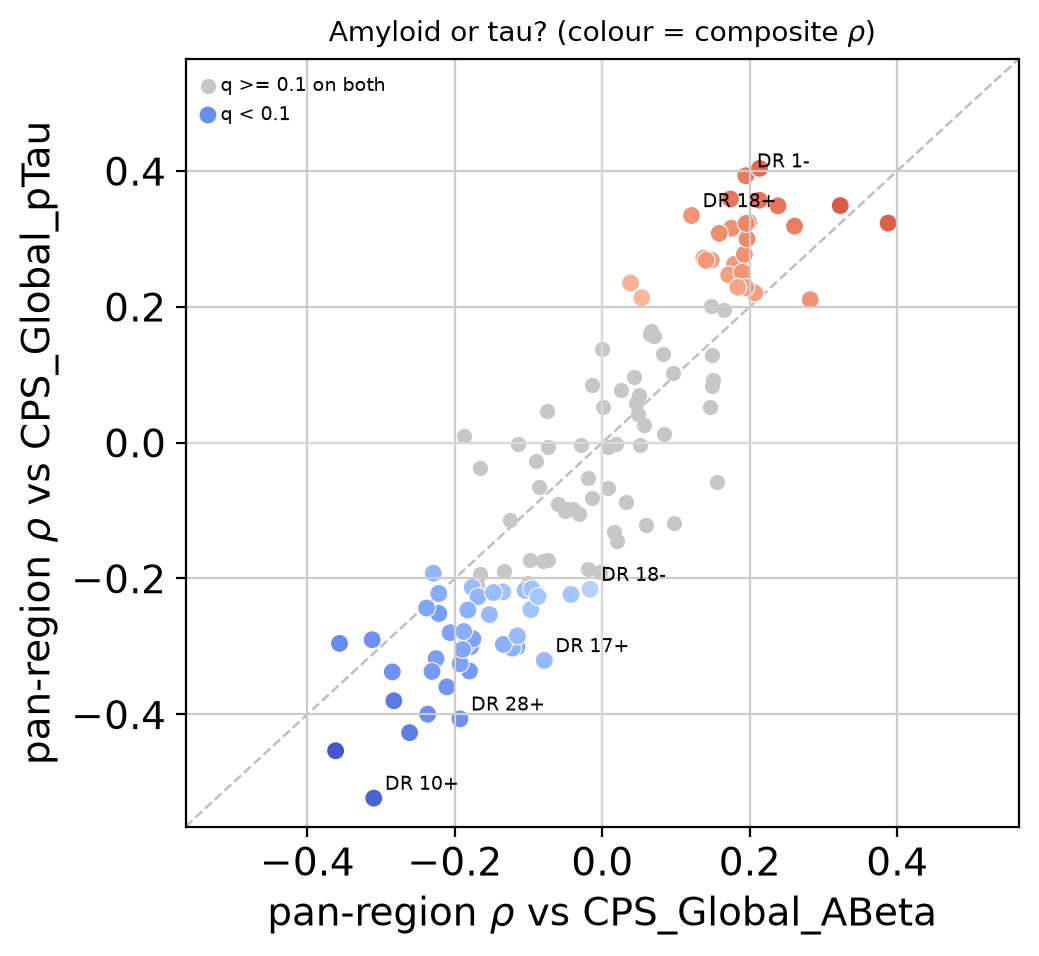

In [20]:
# Off the diagonal is component-specific; on it, the direction tracks whatever the two
# scores share. The dashed line is equality, not a fit -- and because the scores themselves
# correlate strongly, points sit nearer the diagonal than true specificity would put them.
fig, ax = plt.subplots(figsize=(5.4, 5.0))
lim = 1.08 * pathology[["ABeta_slope", "pTau_slope"]].abs().to_numpy().max()
ax.plot([-lim, lim], [-lim, lim], ls="--", color="0.75", lw=0.9, zorder=0)
ax.axhline(0, color="0.85", lw=0.8)
ax.axvline(0, color="0.85", lw=0.8)

hit = pathology["best_q"] < Q_CUT
ax.scatter(pathology.loc[~hit, "ABeta_slope"], pathology.loc[~hit, "pTau_slope"],
           s=20, color="0.78", label=f"q >= {Q_CUT} on both")
ax.scatter(pathology.loc[hit, "ABeta_slope"], pathology.loc[hit, "pTau_slope"],
           s=42, c=pathology.loc[hit, "composite_slope"], cmap="coolwarm",
           vmin=-0.7, vmax=0.7, edgecolor="white", linewidth=0.4, label=f"q < {Q_CUT}")
for name in pathology.loc[hit, "gap"].abs().nlargest(6).index:
    ax.annotate(name, (pathology.loc[name, "ABeta_slope"], pathology.loc[name, "pTau_slope"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set(xlim=(-lim, lim), ylim=(-lim, lim),
       xlabel="standardized slope vs CPS_Local_ABeta",
       ylabel="standardized slope vs CPS_Local_pTau")
ax.set_title("Amyloid or tau? (colour = composite slope)", fontsize=10)
ax.legend(fontsize=7, frameon=False, loc="upper left")
fig.tight_layout()

In [21]:
# The scatter is lopsided, so test the lopsidedness rather than eyeballing it: across every
# live direction, is the tau slope larger in magnitude than the amyloid one?
leans_ptau = pathology["pTau_slope"].abs() > pathology["ABeta_slope"].abs()
signed_rank = stats.wilcoxon(pathology["pTau_slope"].abs(), pathology["ABeta_slope"].abs())
print(f"|slope| larger for pTau in {int(leans_ptau.sum())} of {len(pathology)} directions "
      f"(Wilcoxon signed-rank p = {signed_rank.pvalue:.1e})")
print("median |slope|: " + ", ".join(
    f"{label} {pathology[f'{label}_slope'].abs().median():.3f}" for label in MODELS))

# Two things that would produce the same pattern without any tau specificity, both
# measurable: a score with more spread across units correlates better with anything, and
# the composite is itself nearer one component than the other.
component = {"composite": "CPS_Local", "ABeta": "CPS_Local_ABeta", "pTau": "CPS_Local_pTau"}
spread = scores[list(component.values())].dropna()
print("\nunit-score IQR:     " + ", ".join(
    f"{label} {spread[col].quantile(0.75) - spread[col].quantile(0.25):.3f}"
    for label, col in component.items()))
for label in ("pTau", "ABeta"):
    rho = stats.spearmanr(spread["CPS_Local"], spread[component[label]]).statistic
    print(f"composite vs {label:6s}: {rho:.3f}")

|rho| larger for pTau in 99 of 124 directions (Wilcoxon signed-rank p = 6.6e-13)
median |pan-region rho|: composite 0.202, ABeta 0.144, pTau 0.217

donor-score IQR:      composite 0.452, ABeta 0.444, pTau 0.522
composite vs pTau:    0.940
composite vs ABeta:   0.879


The lean is cohort-wide, not a property of a few directions: most live directions have a
larger slope against tau than against amyloid, and the signed-rank test on the paired
magnitudes is not close. The honest reading is therefore about the latent space as a whole
— **these factors track tau burden more closely than amyloid burden** — rather than about
any single direction being tau-specific.

Two alternative explanations are printed above rather than waved away: a score with more
spread across units lifts every association with it, and the composite is itself nearer one
component than the other, so a direction fit to track "progression" inherits some of that.
Read them before reading the gap.

The per-direction gaps in the table above are the weaker claim, and should be read with the
correlation between the two components firmly in mind — no direction here is clean evidence
of amyloid-specific or tau-specific biology on its own.

## 9 — Compositional context

`/data/multiregion/pertpy/CPS_Local/` holds a finished scCODA compositional
analysis of all 174 supertypes against `CPS_Local`. The cells below read it and
ask whether the directions that track CPS mark the supertypes scCODA says are
depleted. See the analysis README for the four caveats about how to use it.

In [22]:
# Three values with three meanings, which a naive fillna(0) would collapse into one:
# NaN  -- the supertype has no nuclei in that region, so it was never modelled
# 0.0  -- modelled, but scCODA did not call the effect credible
# else -- a credible shift in that supertype's share, negative meaning depleted
summary_path = sorted(S.CPS_LOCAL_DIR.glob(S.SCCODA_SUMMARY_GLOB))[-1]
summary = pd.read_csv(summary_path, index_col=0)
effects = (summary[summary["Cell Type"].isin(SUPERTYPES)]
           .pivot(index="Cell Type", columns="Region", values="Local Model"))
effects.columns.name = None

print(f"{summary_path.name}: {effects.shape[0]} supertypes x {effects.shape[1]} regions -- "
      f"{int((effects.fillna(0) != 0).to_numpy().sum())} credible, "
      f"{int((effects == 0).to_numpy().sum())} not credible, "
      f"{int(effects.isna().to_numpy().sum())} not modelled")
effects.round(2)

,AnG,DFC,FI,HIP,ITG,LEC,MEC,MTG,STG,V1C
Cell Type,,,,,,,,,,
Sst_1,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00
Sst_10,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sst_11,-0.88,-0.88,-0.88,NaN,-0.88,-0.88,-0.88,-1.57,-0.88,NaN
Sst_12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sst_13,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42
Sst_19,-0.74,-0.74,-0.74,NaN,-0.74,-0.74,-0.74,-1.39,-0.74,-0.74
Sst_2,-0.83,-0.83,-0.83,NaN,-0.83,-0.83,-0.83,-1.74,-0.83,-0.83
Sst_20,-0.96,-0.96,-0.96,NaN,-0.96,-0.96,-0.96,-1.90,-0.96,-0.96
Sst_22,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,NaN


### That table has ten columns and does not have ten measurements

The shape invites a supertype × region heatmap. Before drawing one: independent per-region
MCMC fits cannot agree to six decimal places, and across the SST supertypes this table's
effect is a single value repeated over every region the supertype appears in — MTG,
SEA-AD's separately-fit flagship region, being the one exception. Reading it as ten
regional measurements would multiply the evidence by ten.

In [23]:
# Is the delivered effect actually region-specific, or one value repeated? Independent
# per-region MCMC fits cannot agree to six decimal places, so a supertype whose row takes
# a single value across every region it appears in is one fit broadcast, and reading it as
# ten regional measurements would multiply the evidence by ten.
rows = {}
for supertype, values in effects.iterrows():
    present = values.dropna()
    if present.empty:
        continue
    mode = present.mode()
    shared = float(mode.iloc[0]) if len(mode) else np.nan
    rows[supertype] = {
        "n_regions": len(present),
        "n_distinct": int(present.nunique()),
        "shared_effect": shared,
        "deviating_regions": ", ".join(present.index[present != shared]) or "-",
    }
specificity = pd.DataFrame(rows).T.astype(
    {"n_regions": int, "n_distinct": int, "shared_effect": float})
specificity.index.name = "Cell Type"

print(f"{int((specificity['n_distinct'] == 1).sum())} of {len(specificity)} supertypes carry "
      "one value across every region they appear in")
print("deviating regions seen:",
      sorted({r for entry in specificity["deviating_regions"] for r in entry.split(", ")
              if r != "-"}))
specificity

11 of 19 supertypes carry one value across every region they appear in
deviating regions seen: ['MTG']


,n_regions,n_distinct,shared_effect,deviating_regions
Cell Type,,,,
Sst_1,9,1,0.000000,-
Sst_10,10,1,0.000000,-
Sst_11,8,2,-0.878724,MTG
Sst_12,10,1,0.000000,-
Sst_13,10,1,-0.424789,-
Sst_19,9,2,-0.742641,MTG
Sst_2,9,2,-0.828178,MTG
Sst_20,9,2,-0.961262,MTG
Sst_22,9,1,-0.450876,-


So the usable scCODA quantity for the SST cohort is **one CPS_Local abundance effect per
supertype** (`shared_effect`), not a regional map. That is worth stating plainly, because
the regional resolution this notebook does have comes from the latent space, which is computed
from the latent space rather than read off this table.

In [24]:
# Significance here is the posterior inclusion probability, *not* `Final Parameter != 0`:
# in the sweep a zero marks only a reference's own self-row, so counting non-zeros would
# score every effect at 1 - 1/174 regardless of the evidence. Those self-rows are dropped
# and the threshold is applied to inclusion instead, at a cut recovered from where the
# summary's own credible/not-credible calls fall.
#
# Read in chunks: the neuronal results file is ~180 MB of which one covariate is wanted,
# and materialising all 2.0M rows to keep 0.3M is pure waste.
SWEEP_COLUMNS = ["Region", "Covariate", "Cell Type", "Final Parameter",
                 "Inclusion probability", "Reference Cell Type"]

chunks = []
for path in sorted(S.CPS_LOCAL_DIR.glob(S.SCCODA_RESULTS_GLOB)):
    for chunk in pd.read_csv(path, usecols=SWEEP_COLUMNS, chunksize=500_000):
        chunk = chunk[(chunk["Covariate"] == "CPS_Local")
                      & chunk["Cell Type"].isin(SUPERTYPES)]
        if len(chunk):
            chunks.append(chunk)

swept = pd.concat(chunks, ignore_index=True)
swept = swept[swept["Cell Type"] != swept["Reference Cell Type"]]
by_cell_region = swept.groupby(["Cell Type", "Region"], observed=True)
effect, inclusion = by_cell_region["Final Parameter"], by_cell_region["Inclusion probability"]
sweep = pd.DataFrame({
    "n_references": effect.size(),
    "median_effect": effect.median(),
    # The spread over reference choices is the uncertainty this sweep exists to expose,
    # and it is not the posterior SD of any one fit.
    "effect_p05": effect.quantile(0.05),
    "effect_p95": effect.quantile(0.95),
    "median_inclusion": inclusion.median(),
    "frac_credible": inclusion.apply(
        lambda v: float((v >= S.SCCODA_INCLUSION_THRESHOLD).mean())),
})
global_fit = sweep.xs("Global", level="Region").sort_values("median_effect")

print(f"{len(sweep)} supertype x region cells from "
      f"{int(sweep['n_references'].median())} references each")
print(f"credibility cut on median inclusion probability: {S.SCCODA_INCLUSION_THRESHOLD}")
agreement = pd.DataFrame({
    "summary": specificity["shared_effect"],
    "sweep_Global": global_fit["median_effect"],
    "median_inclusion": global_fit["median_inclusion"],
    "frac_references_credible": global_fit["frac_credible"],
})
agreement["summary_credible"] = agreement["summary"] != 0
agreement["difference"] = agreement["summary"] - agreement["sweep_Global"]
agreement.sort_values("sweep_Global").round(3)

credibility cut on median inclusion probability: 0.83


,summary,sweep_Global,median_inclusion,frac_references_credible,summary_credible,difference
Cell Type,,,,,,
Sst_23,-1.124,-1.139,1.000,1.000,True,0.015
Sst_20,-0.961,-0.975,0.960,0.994,True,0.014
Sst_3,-0.883,-0.899,0.960,0.983,True,0.016
Sst_11,-0.879,-0.892,0.920,0.960,True,0.014
Sst_2,-0.828,-0.843,0.920,0.965,True,0.015
Sst_25,-0.776,-0.787,0.920,0.988,True,0.012
Sst_19,-0.743,-0.756,0.920,0.965,True,0.014
Sst_22,-0.451,-0.461,0.841,0.572,True,0.010
Sst_13,-0.425,-0.438,0.909,0.861,True,0.013


### The summary *is* the region-agnostic fit

Read the table down the `difference` column. Wherever the summary calls an effect credible
it reproduces the sweep's `Global` estimate to within 0.016, and the supertypes it writes
as `0.0` are exactly those whose median inclusion probability falls below the cut — the
boundary runs between `Sst_9` at 0.815 (zeroed) and `Sst_22` at 0.841 (kept).

Two rows depart from that. `Sst_27-SEAAD` exists only in V1C and takes V1C's own fit
(−1.132 there, against +0.005 globally). And MTG, which the table above does not show,
matches neither the sweep's MTG rows nor `Global` — those cells come from outside this
file, so an MTG value is a different study's answer rather than a regional contrast.

So there is nothing to reconcile between the two artifacts: the summary gives the
delivered, thresholded effect, and the sweep gives the evidence behind it — the inclusion
probability, and how far the estimate travels when the reference cell type changes.

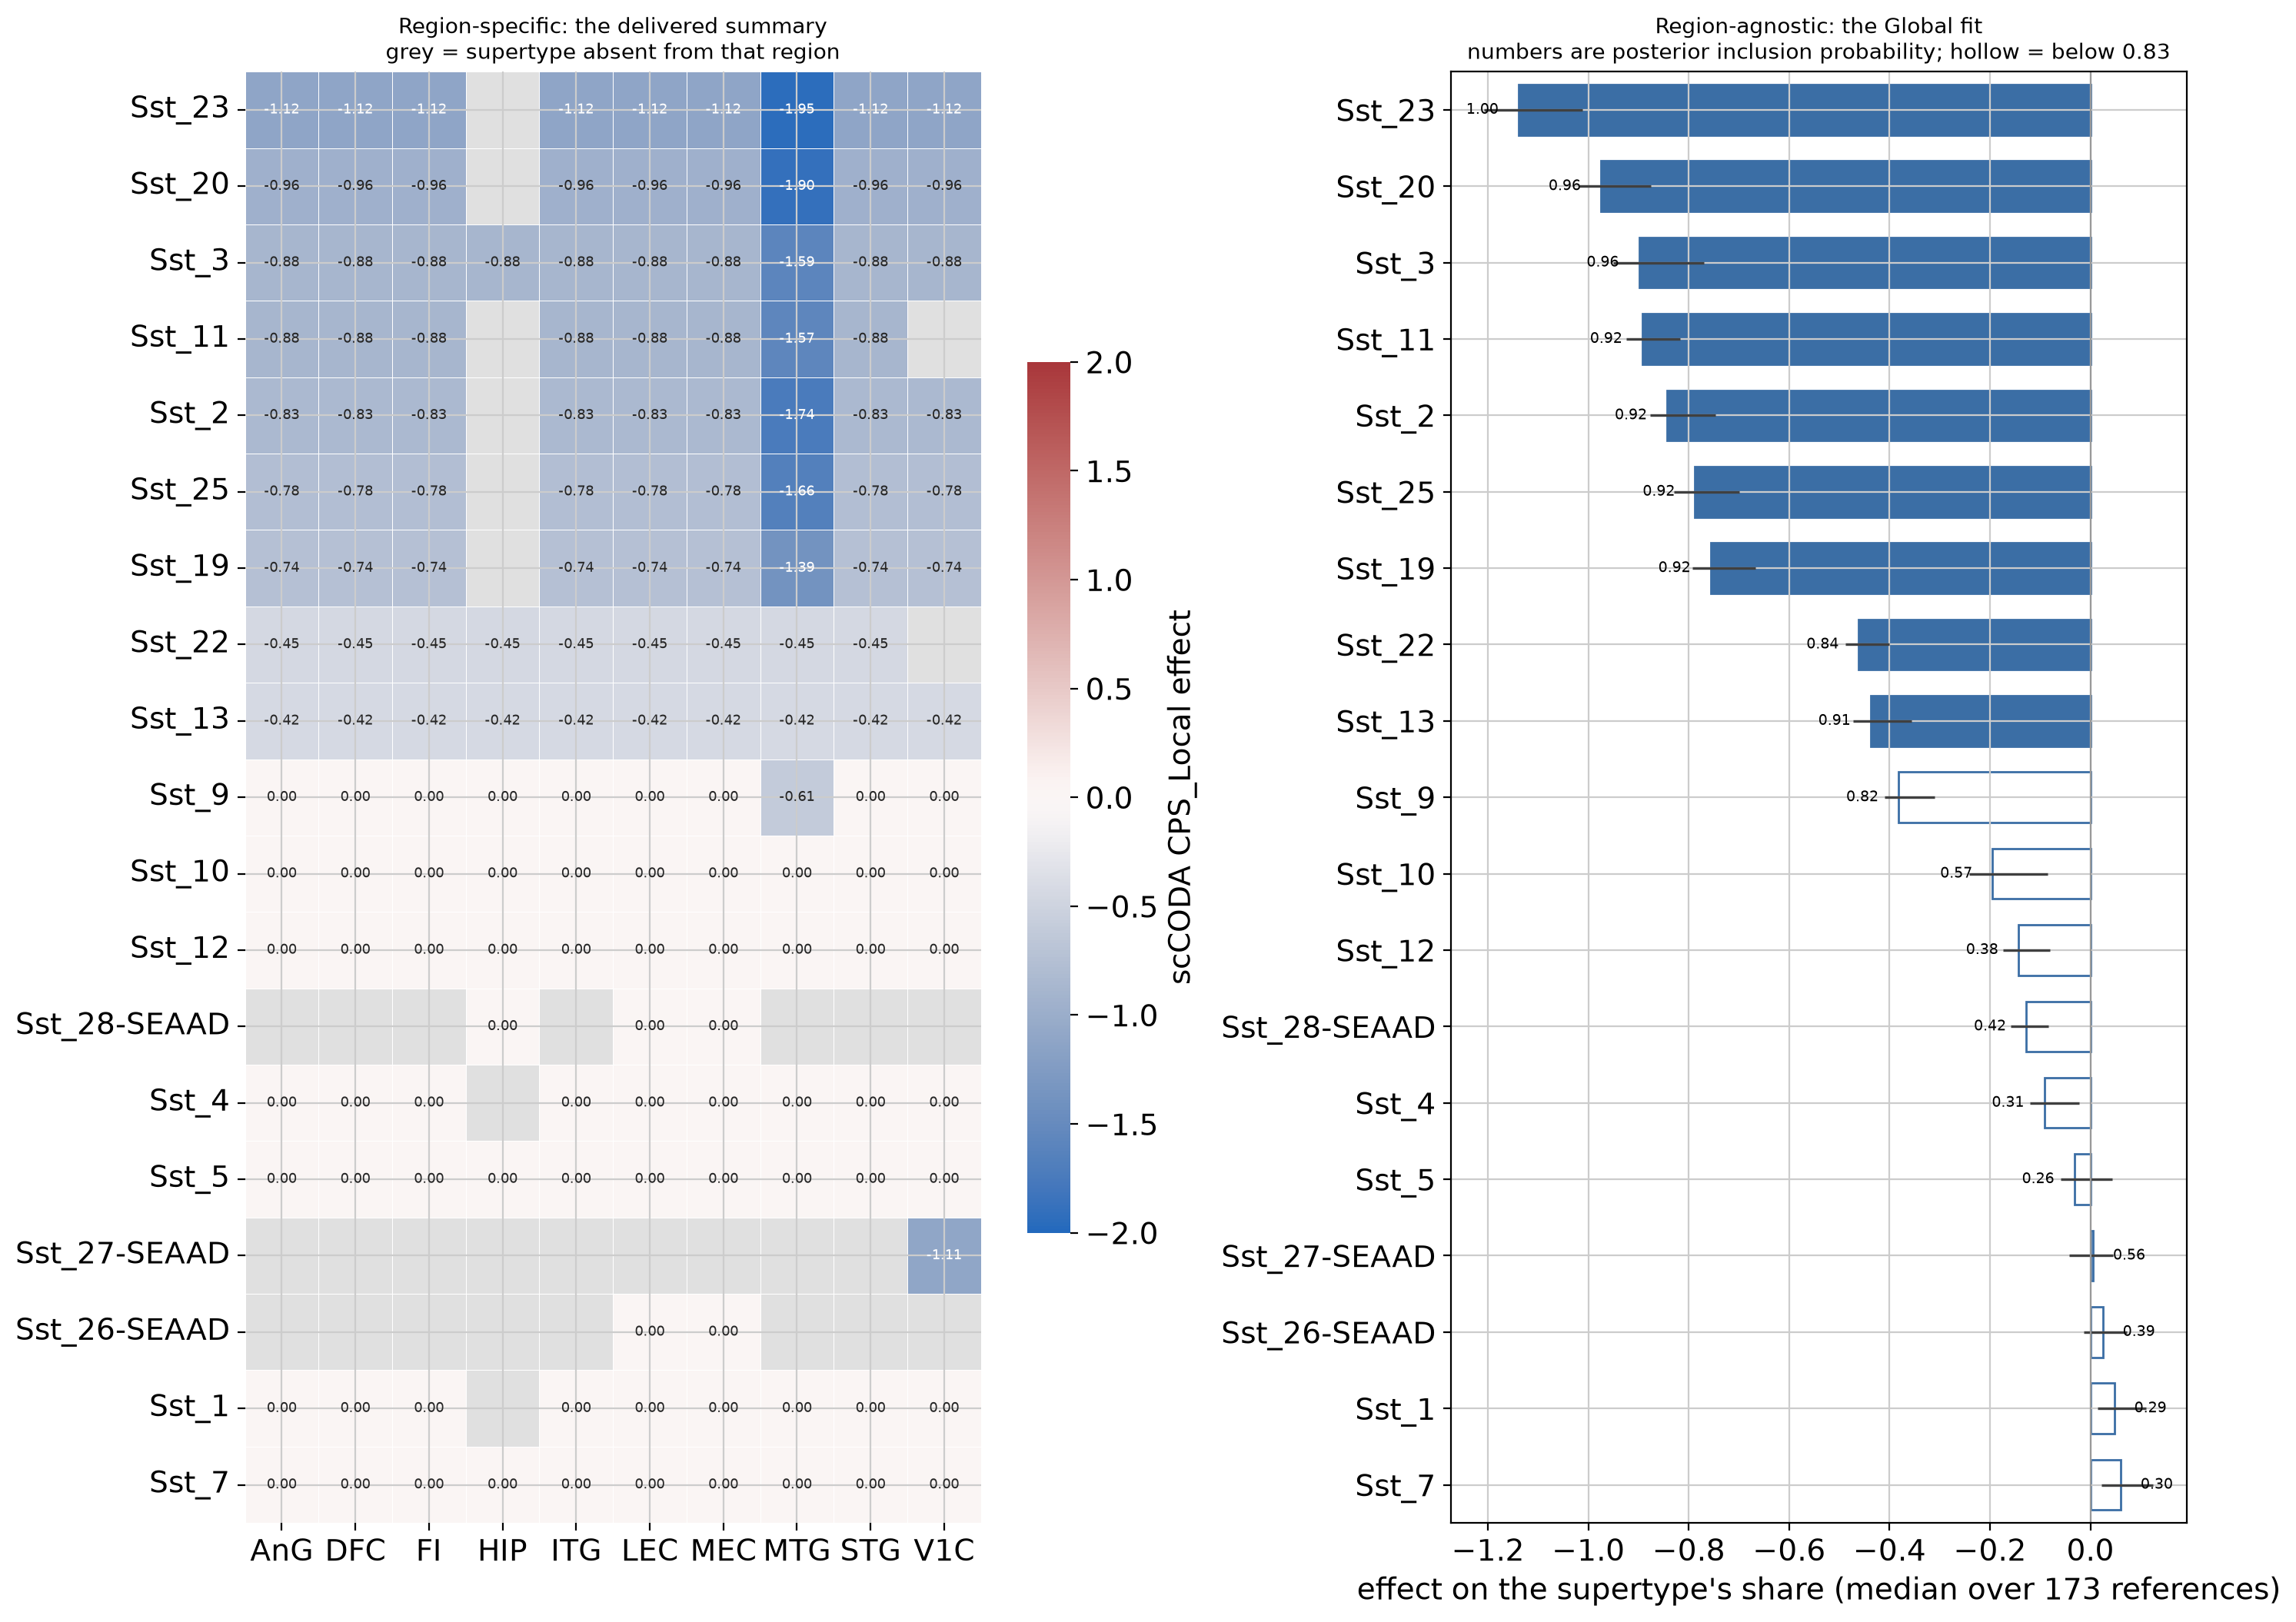

In [25]:
# Left: the delivered per-region table -- one estimate broadcast, MTG excepted, which is
# why most rows are a flat band. Right: the region-agnostic Global fit with its evidence.
# The bar is the median effect over the 173 reference choices, the whisker their 5th-95th
# percentile, the number the median posterior inclusion probability, and a hollow bar
# falls below the credibility cut.
order = global_fit.index
fig, axes = plt.subplots(1, 2, figsize=(14.5, 0.42 * len(order) + 2.8),
                         gridspec_kw={"width_ratios": [1.25, 1]})

axes[0].set_facecolor("0.88")          # NaN = supertype absent from that region
sns.heatmap(effects.reindex(order), cmap="vlag", center=0, vmin=-2, vmax=2,
            annot=True, fmt=".2f", annot_kws={"fontsize": 6.5}, linewidths=0.3,
            cbar_kws={"label": "scCODA CPS_Local effect", "shrink": 0.6}, ax=axes[0])
axes[0].set_title("Region-specific: the delivered summary\n"
                  "grey = supertype absent from that region", fontsize=10)
axes[0].set_xlabel("")
axes[0].set_ylabel("")

credible = (global_fit["median_inclusion"] >= S.SCCODA_INCLUSION_THRESHOLD).to_numpy()
y = np.arange(len(order))
axes[1].barh(y, global_fit["median_effect"], height=0.66,
             color=np.where(credible, "#3b6ea5", "white"), edgecolor="#3b6ea5")
axes[1].hlines(y, global_fit["effect_p05"], global_fit["effect_p95"], color="0.25", lw=1.2)
for position, (_, row) in enumerate(global_fit.iterrows()):
    left = row["median_effect"] < 0
    axes[1].text(row["median_effect"] + (-0.04 if left else 0.04), position,
                 f"{row['median_inclusion']:.2f}", fontsize=7, va="center",
                 ha="right" if left else "left")
axes[1].axvline(0, color="0.6", lw=0.8)
axes[1].set(yticks=y, yticklabels=order, ylim=(len(order) - 0.5, -0.5),
            xlabel="effect on the supertype's share (median over 173 references)")
axes[1].set_title(f"Region-agnostic: the Global fit\nnumbers are posterior inclusion "
                  f"probability; hollow = below {S.SCCODA_INCLUSION_THRESHOLD}", fontsize=10)
fig.tight_layout()

In [26]:
# An independent read on the sign, straight from scCODA's own input counts: the raw
# Spearman of each supertype's share of the neuronal composition against CPS_Local.
# No compositional model, no reference cell type, no shrinkage. It cannot replace the
# model -- shares are not independent, which is the problem scCODA exists to solve --
# but a credible effect whose raw share trends the other way should be flagged, not used.
count_frames, count_metas = [], []
for path in sorted(S.SCCODA_OBJECTS_DIR.glob(S.SCCODA_ABUNDANCE_GLOB)):
    abundance = ad.read_h5ad(path)
    frame = pd.DataFrame(np.asarray(abundance.X), index=abundance.obs_names,
                         columns=abundance.var_names)
    wanted = [column for column in frame.columns if column in set(SUPERTYPES)]
    if not wanted:
        continue
    info = abundance.obs.copy()
    # Over every supertype in the file, before restriction: scCODA fit the full
    # composition of its class group, so a share taken within the SST subset is not the
    # quantity its effects describe.
    info["total"] = frame.sum(axis=1)
    count_frames.append(frame[wanted])
    count_metas.append(info)

counts, count_meta = pd.concat(count_frames), pd.concat(count_metas)
shares = counts.div(count_meta.loc[counts.index, "total"], axis=0)

rows = []
for region, index in count_meta.groupby("Brain Region", observed=True).groups.items():
    index = counts.index.intersection(index)
    scores = pd.to_numeric(count_meta.loc[index, "CPS_Local"], errors="coerce")
    usable_libraries = index[scores.notna().to_numpy()]
    if len(usable_libraries) < 10:
        continue
    for supertype in shares.columns:
        share = shares.loc[usable_libraries, supertype]
        if share.nunique() <= 1:
            continue
        result = stats.spearmanr(share.to_numpy(), scores[usable_libraries].to_numpy())
        rows.append({"Cell Type": supertype, "Brain Region": region,
                     "n_libraries": len(usable_libraries),
                     "rho": result.statistic, "p": result.pvalue})
raw = pd.DataFrame(rows)
# Correct over the finite p-values only: scipy rejects a NaN outright, and a supertype
# whose share never varied should not count toward the number of tests.
p_values = raw["p"].to_numpy(float)
raw["q"] = np.nan
usable = np.isfinite(p_values)
raw.loc[usable, "q"] = stats.false_discovery_control(p_values[usable], method="bh")

check = (raw.groupby("Cell Type")["rho"].median().rename("median_share_rho")
         .to_frame()
         .join(specificity["shared_effect"]))
check["credible"] = check["shared_effect"] != 0
check["disagrees"] = check["credible"] & (
    np.sign(check["median_share_rho"]) != np.sign(check["shared_effect"]))
print(f"{int(check['credible'].sum())} supertypes with a credible scCODA effect; "
      f"sign disagreement with the raw shares in {int(check['disagrees'].sum())} of them")
check.sort_values("shared_effect").round(3)

10 supertypes with a credible scCODA effect; sign disagreement with the raw shares in 1 of them


,median_share_rho,shared_effect,credible,disagrees
Cell Type,,,,
Sst_23,-0.212,-1.124,True,False
Sst_27-SEAAD,-0.281,-1.106,True,False
Sst_20,-0.177,-0.961,True,False
Sst_3,-0.126,-0.883,True,False
Sst_11,-0.170,-0.879,True,False
Sst_2,-0.237,-0.828,True,False
Sst_25,-0.118,-0.776,True,False
Sst_19,-0.041,-0.743,True,False
Sst_22,-0.070,-0.451,True,False


### 9b — Supertype link

This is where the two strands join: section 4 found directions that track CPS;
section 9a found supertypes whose abundance is depleted with CPS. Do the
directions that survive the within-supertype test mark the depleted supertypes?

In [27]:
# Mean activity per supertype, z-scored down each column so a globally strong direction
# does not dominate the comparison with scCODA's effects.
profile = split_by_sign(embed).groupby(embed.obs["Supertype"], observed=True).mean()
profile = (profile - profile.mean()) / profile.std(ddof=0).mask(lambda s: s == 0)

vulnerability = specificity["shared_effect"].reindex(profile.index)
usable = vulnerability.notna()
print(f"{int(usable.sum())} supertypes with an scCODA effect, "
      f"{int((vulnerability[usable] != 0).sum())} of them credible")

link = pd.DataFrame({
    "profile_vs_vulnerability": profile[usable.to_numpy()].corrwith(
        vulnerability[usable], method="spearman"
    ),
    "composite_slope": MODELS["composite"]["coef"],
    "composite_q": MODELS["composite"]["q"],
}).dropna()
link["composition_marker"] = link["profile_vs_vulnerability"].abs() > 0.5
link.reindex(link["composite_slope"].abs().sort_values(ascending=False).index).head(15).round(3)

19 supertypes with an scCODA effect, 10 of them credible


,profile_vs_vulnerability,region_rho,within_supertype_rho,within_supertype_agreement,composition_driven
DR 42-,0.343,0.147,0.186,0.829,False
DR 42+,0.358,-0.201,-0.216,0.829,False
DR 1+,0.480,-0.179,-0.103,0.780,False
DR 40+,0.050,0.232,0.126,0.780,False
DR 38+,0.226,0.042,-0.110,0.765,False
DR 12-,0.532,-0.030,-0.122,0.756,True
DR 14-,0.504,-0.075,-0.166,0.756,True
DR 31+,-0.039,-0.218,-0.113,0.756,False
DR 10+,-0.032,-0.284,-0.164,0.744,False
DR 43+,0.271,-0.077,-0.155,0.744,False


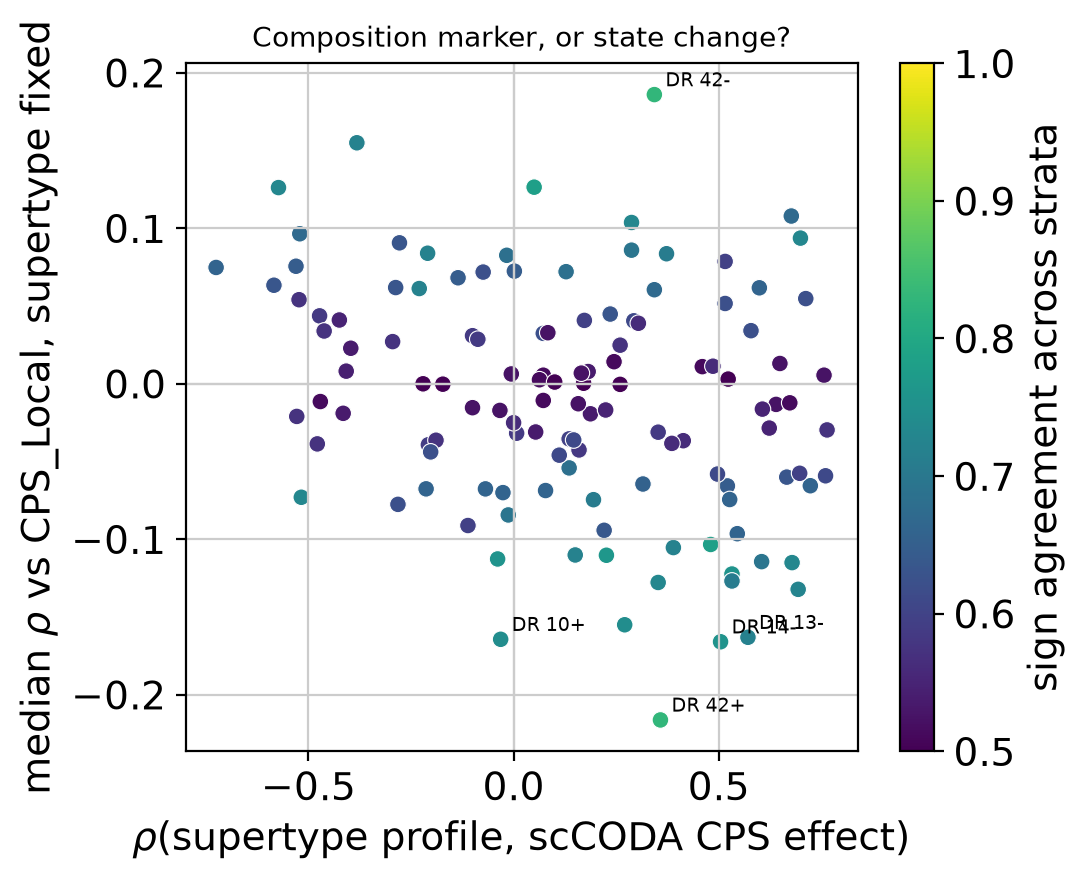

In [28]:
# x: does the direction mark the supertypes scCODA calls depleted?
# y: how strongly does it track CPS_Local (composite pan slope)?
# Bottom-left / top-left split: composition marker that tracks CPS vs. direction
# that tracks CPS without being a composition marker.
fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.axhline(0, color="0.8", lw=0.8)
ax.axvline(0, color="0.8", lw=0.8)
points = ax.scatter(
    link["profile_vs_vulnerability"],
    link["composite_slope"],
    c=-np.log10(link["composite_q"].clip(lower=1e-300)),
    cmap="viridis", s=36, edgecolor="white", linewidth=0.4,
)
for name in link["composite_slope"].abs().nlargest(5).index:
    ax.annotate(name,
                (link.loc[name, "profile_vs_vulnerability"], link.loc[name, "composite_slope"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
fig.colorbar(points, ax=ax, label=r"$-\log_{10}q$, composite CPS")
ax.set(xlabel=r"$\rho$(supertype profile, scCODA CPS effect)",
       ylabel="standardized pan slope vs CPS_Local")
ax.set_title("Composition marker, or state change?", fontsize=10)
fig.tight_layout()

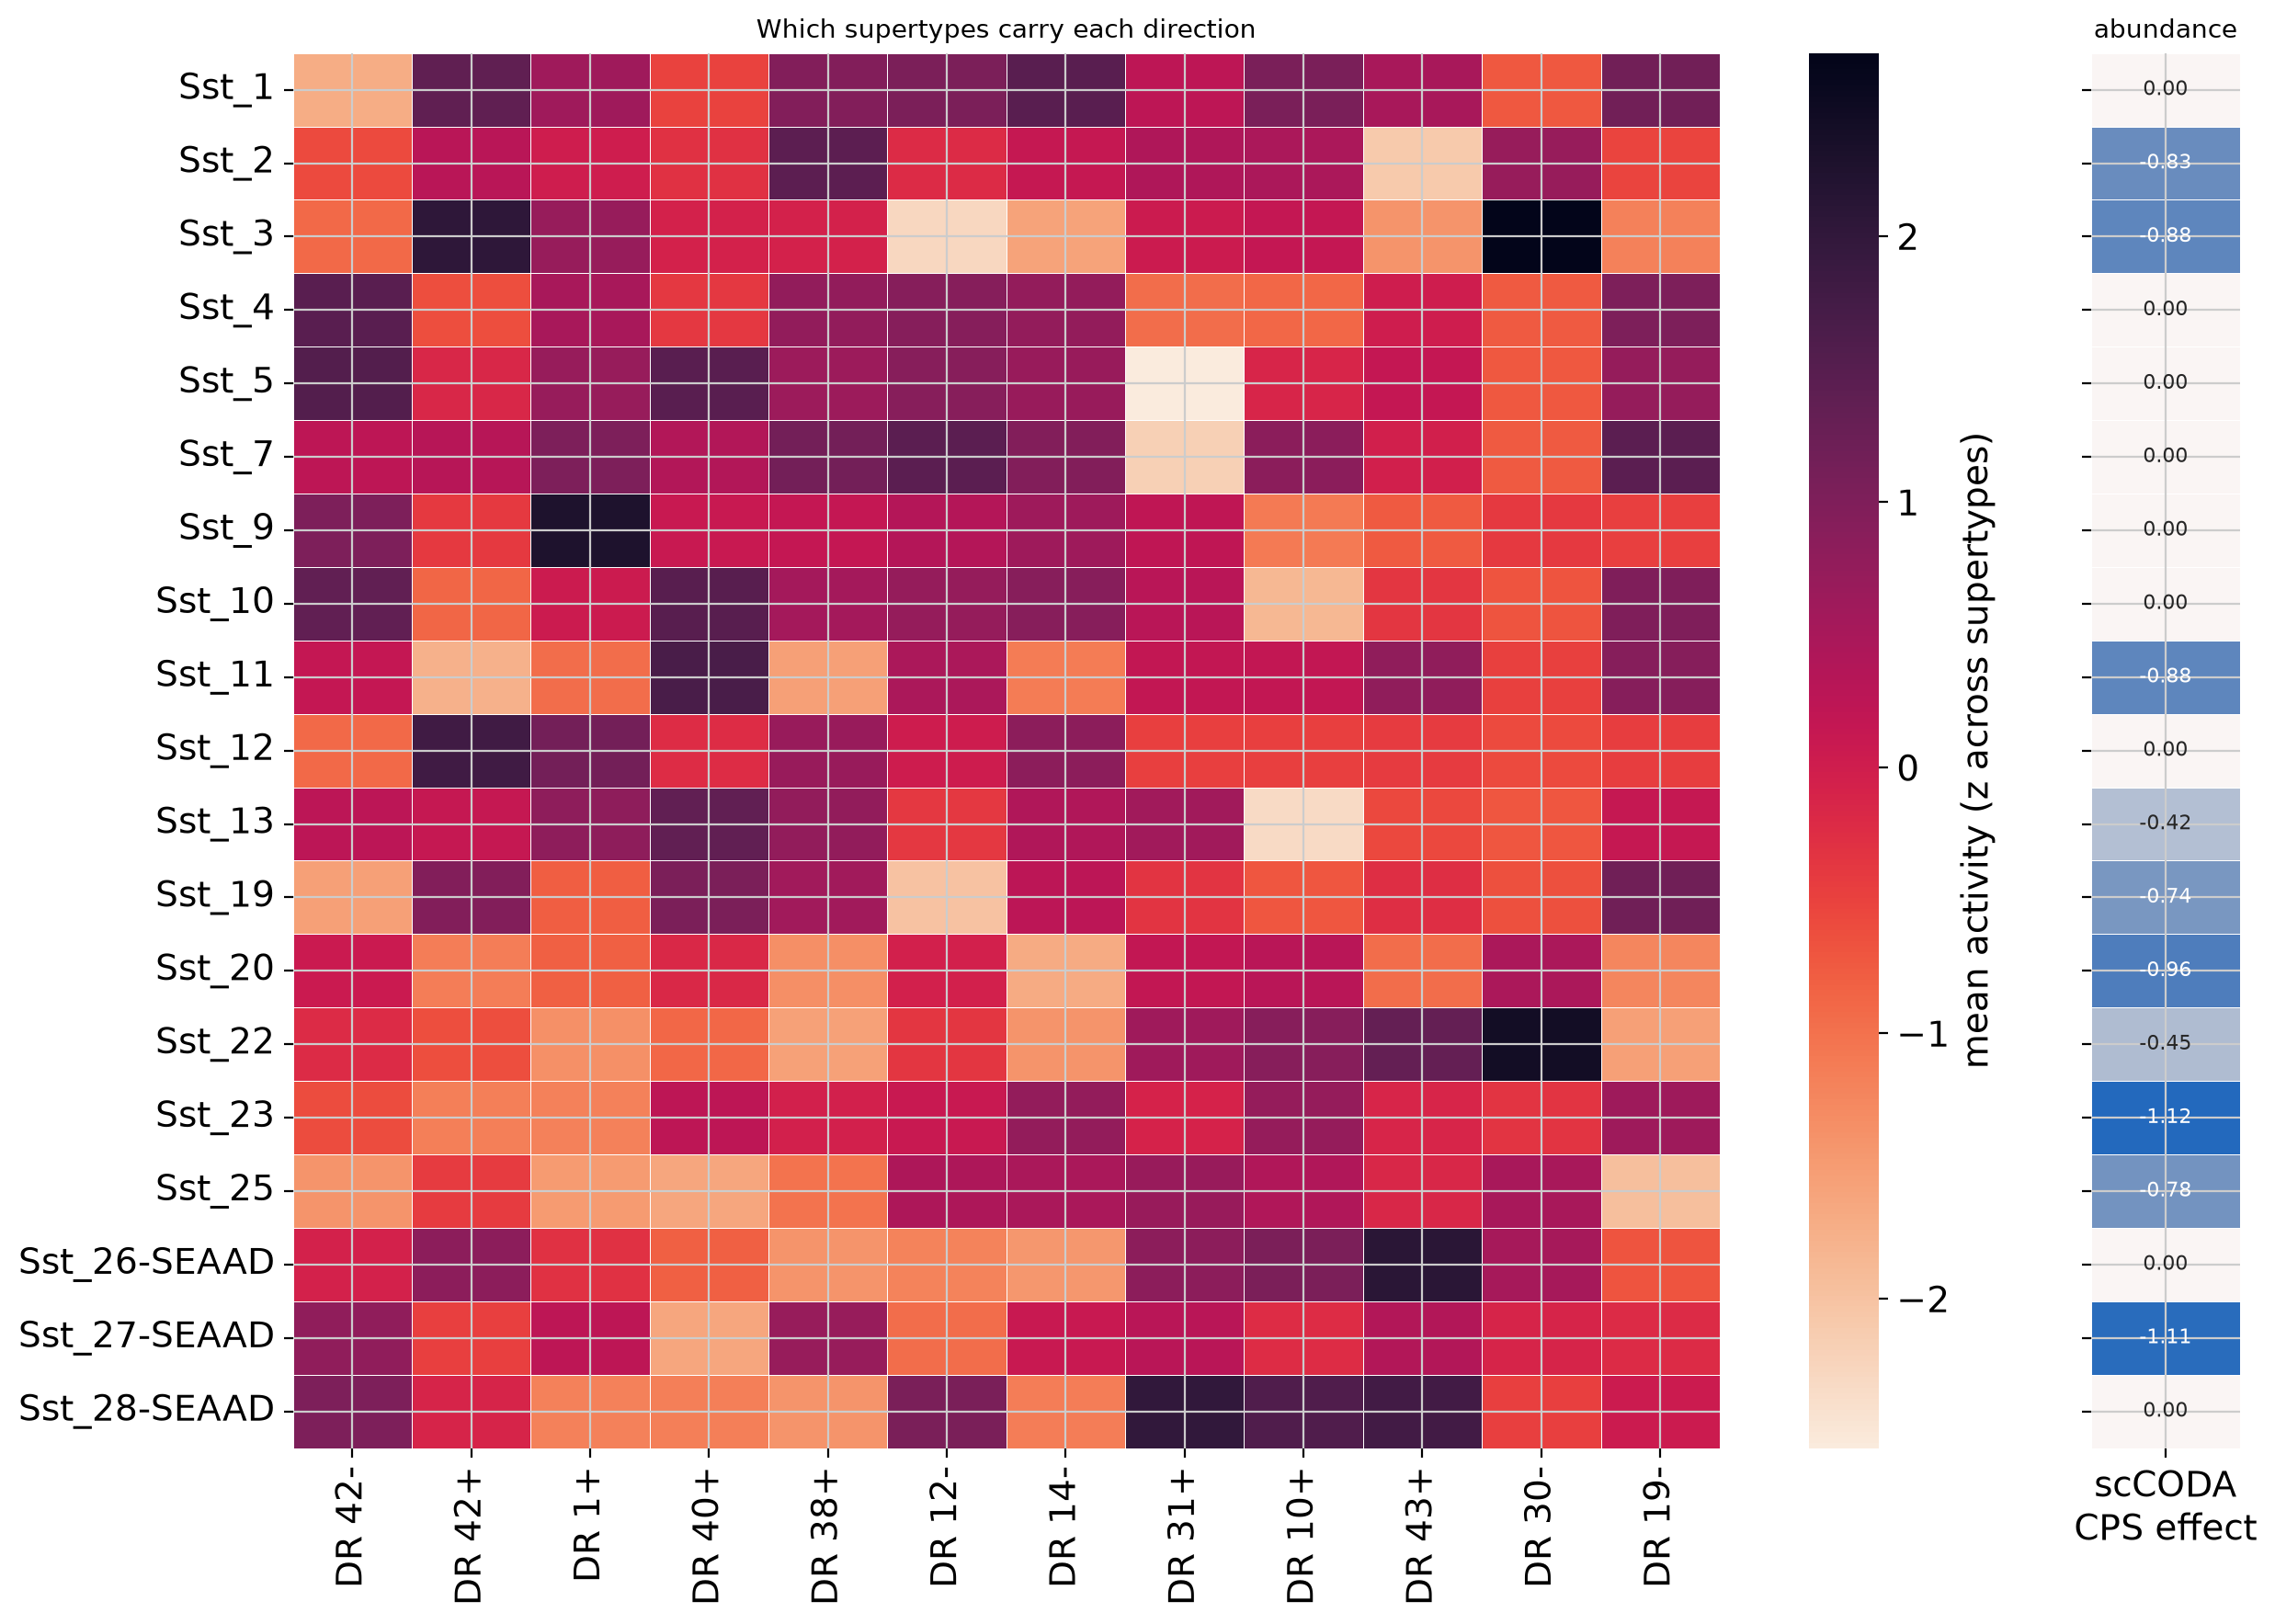

In [29]:
# Supertype profile of the directions with the strongest composite CPS association.
SHOW = 12
chosen = link["composite_slope"].abs().nlargest(SHOW).index
panel = profile[chosen]

fig, axes = plt.subplots(1, 2, figsize=(0.55 * SHOW + 6, 0.36 * len(panel) + 2.2),
                         gridspec_kw={"width_ratios": [SHOW, 1.0]}, sharey=True)
sns.heatmap(panel, cmap="rocket_r", linewidths=0.3, ax=axes[0],
            cbar_kws={"label": "mean activity (z across supertypes)"})
axes[0].set(title="Which supertypes carry each direction", xlabel="", ylabel="")
sns.heatmap(vulnerability.to_frame("scCODA\nCPS effect"), cmap="vlag", center=0,
            annot=True, fmt=".2f", annot_kws={"fontsize": 8}, linewidths=0.3, ax=axes[1],
            cbar=False)
axes[1].set(title="abundance", ylabel="")
fig.tight_layout()

## 10 — Summary

Fill in after looking at the plots above:

- Directions whose `CPS_Local` slope is strongest, and how many survive the
  region-adjusted and within-supertype controls:
- What gene programs do those directions represent?
- Which pathology component (ABeta or pTau) drives the association?
- Do the CPS-tracking directions mark the scCODA-depleted supertypes?

In [30]:
from session_info2 import session_info

session_info(dependencies=True)

Package,Version
pandas,3.0.5
anndata,0.13.3.post0
matplotlib,3.11.1
numpy,2.5.3
scanpy,1.12.4
seaborn,0.13.2
scipy,1.18.0
Component,Info
Python,"3.12.14 (main, Sep 2 2026, 23:27:36) [GCC 15.3.0]"
OS,Linux-6.1.177-224.371.amzn2023.x86_64-x86_64-with-glibc2.35
